Epoch 0, Loss: 3.991962
Epoch 500, Loss: 0.152159
Epoch 1000, Loss: 0.142448
Epoch 1500, Loss: 0.134409
Epoch 2000, Loss: 0.127505
Epoch 2500, Loss: 0.121418
Epoch 3000, Loss: 0.115893
Epoch 3500, Loss: 0.110814
Epoch 4000, Loss: 0.106123
Epoch 4500, Loss: 0.101742

测试集 MSE: 0.104863


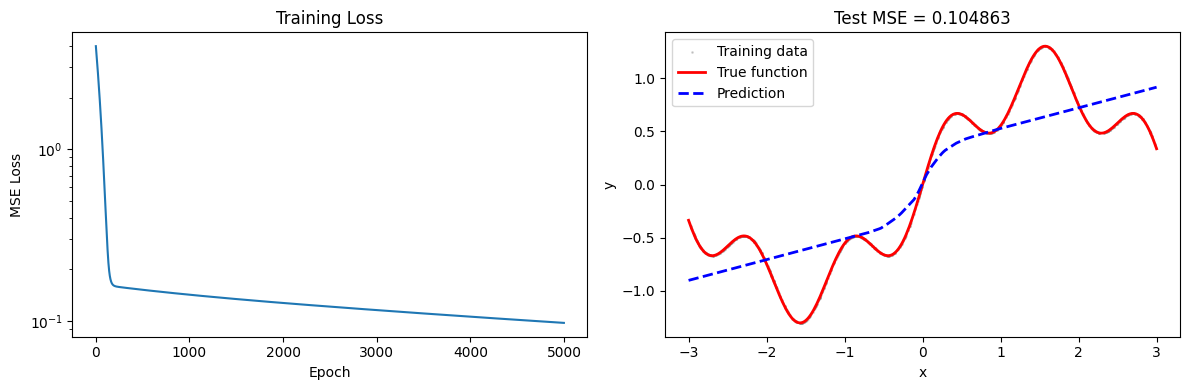

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 函数定义
def target_function(x):
    """定义要拟合的目标函数"""
    return np.sin(x) + 0.3 * np.sin(5 * x)


# 2. 数据采集
np.random.seed(42)
x_train = np.random.uniform(-3, 3, 1000).reshape(-1, 1)
y_train = target_function(x_train)

x_test = np.linspace(-3, 3, 300).reshape(-1, 1)
y_test = target_function(x_test)


# 3. 模型描述
class TwoLayerReLU:
    """两层 ReLU 网络：输入层(1) -> 隐藏层(32) -> 输出层(1)"""
    
    def __init__(self, input_size=1, hidden_size=32, output_size=1, lr=0.01):
        # 参数初始化 (He 初始化)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = lr
        
    def forward(self, x):
        """前向传播"""
        self.z1 = np.dot(x, self.W1) + self.b1
        self.a1 = np.maximum(0, self.z1)      # ReLU 激活
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2
    
    def backward(self, x, y, output):
        """反向传播 (均方误差损失)"""
        m = x.shape[0]        
        # 输出层梯度 (添加数值裁剪)
        dLoss_dz2 = 2 * (output - y) / m        
        # 裁剪梯度防止爆炸
        dLoss_dz2 = np.clip(dLoss_dz2, -10, 10)        
        # 隐藏层到输出层的梯度
        self.dW2 = np.dot(self.a1.T, dLoss_dz2)
        self.db2 = np.sum(dLoss_dz2, axis=0, keepdims=True)        
        # 裁剪权重梯度
        self.dW2 = np.clip(self.dW2, -1, 1)
        self.db2 = np.clip(self.db2, -1, 1)        
        # ReLU 层梯度
        dLoss_da1 = np.dot(dLoss_dz2, self.W2.T)
        dLoss_dz1 = dLoss_da1 * (self.z1 > 0)        
        # 裁剪 ReLU 梯度
        dLoss_dz1 = np.clip(dLoss_dz1, -10, 10)        
        # 输入层到隐藏层的梯度
        self.dW1 = np.dot(x.T, dLoss_dz1)
        self.db1 = np.sum(dLoss_dz1, axis=0, keepdims=True)        
        # 裁剪权重梯度
        self.dW1 = np.clip(self.dW1, -1, 1)
        self.db1 = np.clip(self.db1, -1, 1)
        
    def update(self):
        """参数更新"""
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2
    
    def train_step(self, x, y):
        """单步训练"""
        output = self.forward(x)
        self.backward(x, y, output)
        self.update()
        
        # 添加数值稳定性检查
        loss = np.mean((output - y) ** 2)
        if np.isnan(loss) or np.isinf(loss):
            return 1e10
        return loss
    
    def predict(self, x):
        """预测"""
        return self.forward(x)


# 4. 训练
model = TwoLayerReLU(input_size=1, hidden_size=32, output_size=1, lr=0.001)

epochs = 5000
losses = []

for epoch in range(epochs):
    loss = model.train_step(x_train, y_train)
    losses.append(loss)
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")
    # 如果损失爆炸，提前停止
    if loss > 100:
        print(f"Loss exploded at epoch {epoch}, stopping.")
        break

# 5. 拟合效果
y_pred = model.predict(x_test)
test_mse = np.mean((y_pred - y_test) ** 2)
print(f"\n测试集 MSE: {test_mse:.6f}")

# 可视化
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, s=1, alpha=0.3, label='Training data', color='gray')
plt.plot(x_test, y_test, 'r-', linewidth=2, label='True function')
plt.plot(x_test, y_pred, 'b--', linewidth=2, label='Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Test MSE = {test_mse:.6f}')

plt.tight_layout()
plt.show()

In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 4.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.1 MB 2.7 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.9 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 3.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.1 MB/s eta 0:00:02
   --------------------- -----------------